In [1]:
%load_ext autoreload
%autoreload 2
import torch
from torch import nn
import Systems
import numpy as np
from NN import Main_Network, NN
import matplotlib.pyplot as plt
from Dataset import DataSet
from Normalizer import Normalizer
from Trainer import Trainer
import scipy.io as spio
from Observer import System_z, Observer
import torch.nn.functional as F

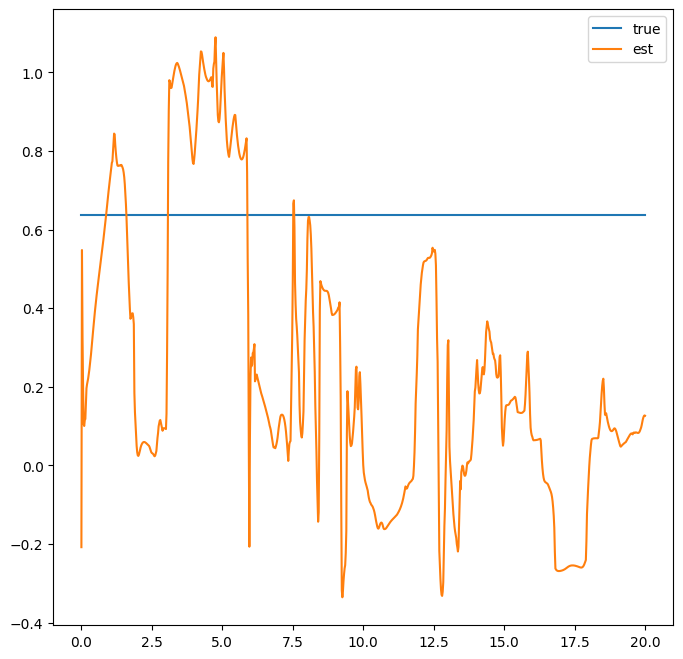

In [22]:
#------------- New England Power System ------------- 
I_ny = np.eye(10)
A = np.diag(np.linspace(-21, -15, 2*20+1))
q = np.ones([2*20+1,1])
M = np.kron(A,I_ny)
K = np.kron(q,I_ny)

n = 10
G = np.ones([n,n])*0.1
B = np.ones([n,n])*0.5
Pm = 0
D = 0
omega0 = 2*np.pi*60
H = np.array([500, 30.3, 35.8, 38.6, 26, 34.8, 26.4, 24.3, 34.5, 42])
E = np.array([1.0368, 1.1966, 1.1491, 1.0808, 1.3971, 1.1910, 1.1394, 1.0709, 1.1368, 1.0929])
system = Systems.New_England_Power(G, B, E, H, D, Pm, omega0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N = 1000
a = 0
b = 20

model_data = torch.load('models/T_inverse_england_lr0.001_batch32_epoch25')
num_hidden = model_data['config']['num_hidden']
hidden_size = model_data['config']['hidden_size']
x_size = model_data['config']['x_size']
z_size = model_data['config']['z_size']
activation = model_data['config']['activation']
normalizer = model_data['config']['normalizer']
T_inv_net = NN(num_hidden, hidden_size, z_size, x_size, activation, normalizer).to(device)
T_inv_net.load_state_dict(model_data['model'])

observer2 = Observer(system, M, K, T_inv_net, a, b, N, init_z_zero=True)

delta0 = np.random.uniform(low=-0.4*np.pi, high = 0.4*np.pi, size=n)
w0 = np.random.uniform(low=-5+120*np.pi, high = 5+120*np.pi, size=n)
initial_conds = np.zeros([1,2*n])
initial_conds [0][::2], initial_conds [0][1::2] = w0, delta0

x, x_hat, t, error = observer2.simulate(initial_conds, add_noise = False)

idx = 13
fig = plt.figure(figsize = (8,8), facecolor='w')
plt.plot(t, x[:,idx], label = 'true')
plt.plot(t, x_hat[:,idx], label = 'est')
plt.legend()
plt.show()

In [5]:
print(x_hat.shape)

(1001, 20)
